# Movie Recommendation System

A simple recommender implementing **two** classic approaches:

1. **Content-Based Filtering** — recommends movies similar in genre/attributes to a movie you like.
2. **Collaborative Filtering** — recommends movies based on what *similar users* rated highly (user-based, using cosine similarity on the user–item rating matrix).

> Uses a small, self-contained synthetic movie + ratings dataset (no external download needed),
> in the style of the classic MovieLens dataset. Swap in real MovieLens CSVs by replacing the
> "Load Data" cell.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

## 1. Load Data

Movies with genres, and a user–movie ratings table.

In [2]:
movies = pd.DataFrame([
    (1,  "The Last Horizon",        "Sci-Fi|Adventure"),
    (2,  "Silent Vows",             "Drama|Romance"),
    (3,  "Codename Falcon",         "Action|Thriller"),
    (4,  "Laugh Track",             "Comedy"),
    (5,  "Midnight Orchard",        "Horror|Mystery"),
    (6,  "Starlight Waltz",         "Romance|Drama"),
    (7,  "Iron Circuit",            "Sci-Fi|Action"),
    (8,  "The Comedy of Errors Inn","Comedy|Romance"),
    (9,  "Shadow Protocol",         "Action|Thriller|Sci-Fi"),
    (10, "Gentle Rain",             "Drama"),
    (11, "Haunted Harbor",          "Horror|Thriller"),
    (12, "Galactic Drift",          "Sci-Fi|Adventure|Action"),
    (13, "Punchline",               "Comedy"),
    (14, "The Detective's Ledger",  "Mystery|Thriller|Drama"),
    (15, "Ever After Grove",        "Romance|Comedy"),
    (16, "Nebula's Edge",           "Sci-Fi|Adventure"),
    (17, "Whispering Pines",        "Horror|Mystery"),
    (18, "Fast Alibi",              "Action|Comedy"),
    (19, "Ashes of Yesterday",      "Drama|Thriller"),
    (20, "Carnival of Lights",      "Adventure|Comedy|Family"),
], columns=["movieId", "title", "genres"])

print(f"{len(movies)} movies")
movies.head()

20 movies


,movieId,title,genres
0,1,The Last Horizon,Sci-Fi|Adventure
1,2,Silent Vows,Drama|Romance
2,3,Codename Falcon,Action|Thriller
3,4,Laugh Track,Comedy
4,5,Midnight Orchard,Horror|Mystery


In [3]:
def generate_ratings(movies, n_users=40, sparsity=0.35, seed=42):
    """Simulates a user-item ratings matrix with genre-based user taste clusters,
    so collaborative filtering has real structure to discover."""
    rng = np.random.default_rng(seed)
    all_genres = sorted(set(g for gl in movies['genres'] for g in gl.split('|')))

    # give each synthetic user 1-2 preferred genres (their 'taste')
    user_tastes = {u: rng.choice(all_genres, size=rng.integers(1, 3), replace=False)
                   for u in range(1, n_users + 1)}

    rows = []
    for u in range(1, n_users + 1):
        taste = set(user_tastes[u])
        for _, m in movies.iterrows():
            if rng.random() > sparsity:  # skip = user hasn't rated this movie
                continue
            m_genres = set(m['genres'].split('|'))
            overlap = len(taste & m_genres)
            base = 2.5 + overlap * 1.3
            rating = np.clip(rng.normal(base, 0.7), 1, 5)
            rows.append((u, m['movieId'], round(rating * 2) / 2))  # round to nearest 0.5

    return pd.DataFrame(rows, columns=['userId', 'movieId', 'rating'])

ratings = generate_ratings(movies)
print(f"{len(ratings)} ratings from {ratings.userId.nunique()} users on {ratings.movieId.nunique()} movies")
ratings.head()

290 ratings from 40 users on 20 movies


,userId,movieId,rating
0,1,5,2.5
1,1,7,2.5
2,1,9,2.0
3,1,10,2.5
4,1,17,2.0


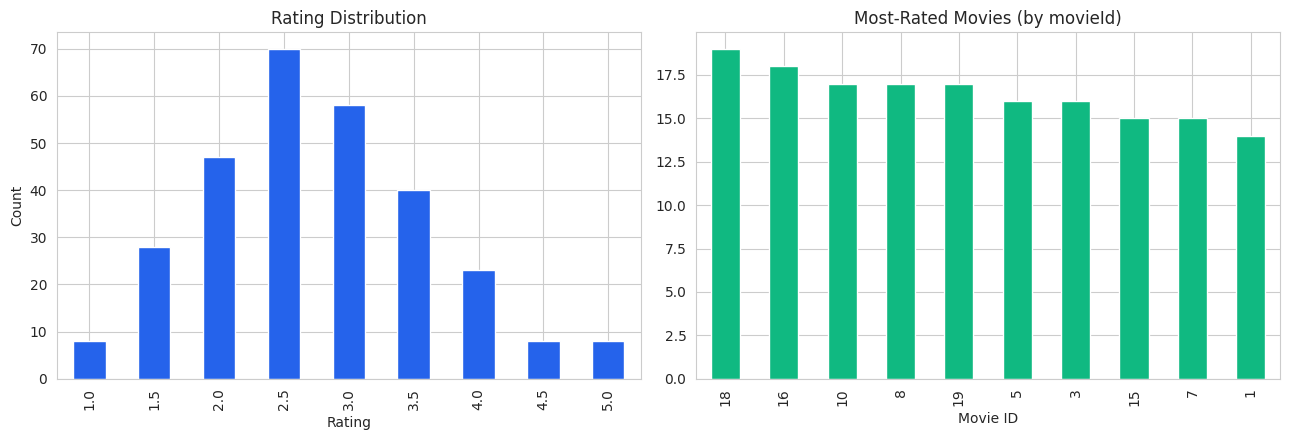

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#2563eb')
axes[0].set_title('Rating Distribution'); axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')

ratings.groupby('movieId').size().sort_values(ascending=False).head(10).plot(kind='bar', ax=axes[1], color='#10b981')
axes[1].set_title('Most-Rated Movies (by movieId)'); axes[1].set_xlabel('Movie ID')
plt.tight_layout(); plt.show()

## 2. Content-Based Filtering

Represents each movie's genres as a vector (multi-hot encoding), then recommends movies most similar in genre composition using **cosine similarity**.

In [5]:
# Multi-hot encode genres
vectorizer = CountVectorizer(tokenizer=lambda x: x.split('|'), token_pattern=None)
genre_matrix = vectorizer.fit_transform(movies['genres'])
genre_sim = cosine_similarity(genre_matrix)

genre_sim_df = pd.DataFrame(genre_sim, index=movies['title'], columns=movies['title'])
print("Genre vocabulary:", vectorizer.get_feature_names_out())
genre_sim_df.iloc[:5, :5].round(2)

Genre vocabulary: ['action' 'adventure' 'comedy' 'drama' 'family' 'horror' 'mystery'
 'romance' 'sci-fi' 'thriller']


title,The Last Horizon,Silent Vows,Codename Falcon,Laugh Track,Midnight Orchard
title,,,,,
The Last Horizon,1.0,0.0,0.0,0.0,0.0
Silent Vows,0.0,1.0,0.0,0.0,0.0
Codename Falcon,0.0,0.0,1.0,0.0,0.0
Laugh Track,0.0,0.0,0.0,1.0,0.0
Midnight Orchard,0.0,0.0,0.0,0.0,1.0


In [6]:
def content_based_recommend(title, n=5):
    if title not in movies['title'].values:
        return f"'{title}' not found in catalog."
    idx = movies.index[movies['title'] == title][0]
    sims = list(enumerate(genre_sim[idx]))
    sims = sorted(sims, key=lambda x: x[1], reverse=True)
    sims = [s for s in sims if s[0] != idx][:n]

    results = pd.DataFrame([
        {'title': movies.iloc[i]['title'], 'genres': movies.iloc[i]['genres'], 'similarity': round(score, 3)}
        for i, score in sims
    ])
    return results

print("Because you liked: Iron Circuit (Sci-Fi|Action)\n")
content_based_recommend("Iron Circuit", n=5)

Because you liked: Iron Circuit (Sci-Fi|Action)



,title,genres,similarity
0,Shadow Protocol,Action|Thriller|Sci-Fi,0.816
1,Galactic Drift,Sci-Fi|Adventure|Action,0.816
2,The Last Horizon,Sci-Fi|Adventure,0.500
3,Codename Falcon,Action|Thriller,0.500
4,Nebula's Edge,Sci-Fi|Adventure,0.500


## 3. Collaborative Filtering (User-Based)

Builds a user–item ratings matrix, finds users with similar rating patterns via **cosine similarity**, then recommends movies those similar users rated highly that the target user hasn't seen yet.

In [7]:
user_item_matrix = ratings.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)
print(f"User-item matrix shape: {user_item_matrix.shape}")
user_item_matrix.iloc[:6, :6]

User-item matrix shape: (40, 20)


movieId,1,2,3,4,5,6
userId,,,,,,
1,0.0,0.0,0.0,0.0,2.5,0.0
2,3.0,0.0,0.0,2.5,0.0,3.0
3,0.0,0.0,0.0,0.0,0.0,2.5
4,2.0,0.0,0.0,3.0,0.0,2.0
5,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,4.0,2.5,0.0,4.0,0.0


In [8]:
user_sim = cosine_similarity(user_item_matrix)
user_sim_df = pd.DataFrame(user_sim, index=user_item_matrix.index, columns=user_item_matrix.index)

def collaborative_recommend(user_id, n=5, k_neighbors=8):
    if user_id not in user_item_matrix.index:
        return f"User {user_id} not found."

    # find k most similar users (excluding self)
    sims = user_sim_df[user_id].drop(user_id).sort_values(ascending=False).head(k_neighbors)

    already_rated = set(user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index)

    # weighted average of neighbor ratings for unseen movies
    scores = {}
    for movie_id in user_item_matrix.columns:
        if movie_id in already_rated:
            continue
        neighbor_ratings = user_item_matrix.loc[sims.index, movie_id]
        rated_mask = neighbor_ratings > 0
        if rated_mask.sum() == 0:
            continue
        weights = sims[rated_mask]
        scores[movie_id] = np.average(neighbor_ratings[rated_mask], weights=weights)

    top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]
    results = pd.DataFrame([
        {'title': movies.loc[movies.movieId == mid, 'title'].values[0],
         'genres': movies.loc[movies.movieId == mid, 'genres'].values[0],
         'predicted_rating': round(score, 2)}
        for mid, score in top
    ])
    return results

target_user = 1
print(f"User {target_user}'s existing ratings:")
print(ratings[ratings.userId == target_user].merge(movies, on='movieId')[['title', 'rating']]
      .sort_values('rating', ascending=False).to_string(index=False))
print(f"\nTop similar users to User {target_user}:")
print(user_sim_df[target_user].drop(target_user).sort_values(ascending=False).head(5).round(3))

User 1's existing ratings:
             title  rating
  Midnight Orchard     2.5
      Iron Circuit     2.5
       Gentle Rain     2.5
Carnival of Lights     2.5
   Shadow Protocol     2.0
  Whispering Pines     2.0
        Fast Alibi     1.5

Top similar users to User 1:
userId
28    0.721
8     0.701
30    0.618
26    0.603
14    0.561
Name: 1, dtype: float64


In [9]:
print(f"Recommended for User {target_user} (Collaborative Filtering):\n")
collaborative_recommend(target_user, n=5)

Recommended for User 1 (Collaborative Filtering):



,title,genres,predicted_rating
0,Nebula's Edge,Sci-Fi|Adventure,4.00
1,Codename Falcon,Action|Thriller,3.18
2,The Detective's Ledger,Mystery|Thriller|Drama,3.11
3,Laugh Track,Comedy,2.90
4,Galactic Drift,Sci-Fi|Adventure|Action,2.75


## 4. Side-by-Side Comparison

In [10]:
liked_movie = "Galactic Drift"
print(f"CONTENT-BASED — because you liked '{liked_movie}':")
display(content_based_recommend(liked_movie, n=5))

print(f"\nCOLLABORATIVE — because similar users to User {target_user} enjoyed:")
display(collaborative_recommend(target_user, n=5))

CONTENT-BASED — because you liked 'Galactic Drift':


,title,genres,similarity
0,The Last Horizon,Sci-Fi|Adventure,0.816
1,Iron Circuit,Sci-Fi|Action,0.816
2,Nebula's Edge,Sci-Fi|Adventure,0.816
3,Shadow Protocol,Action|Thriller|Sci-Fi,0.667
4,Codename Falcon,Action|Thriller,0.408



COLLABORATIVE — because similar users to User 1 enjoyed:


,title,genres,predicted_rating
0,Nebula's Edge,Sci-Fi|Adventure,4.00
1,Codename Falcon,Action|Thriller,3.18
2,The Detective's Ledger,Mystery|Thriller|Drama,3.11
3,Laugh Track,Comedy,2.90
4,Galactic Drift,Sci-Fi|Adventure|Action,2.75


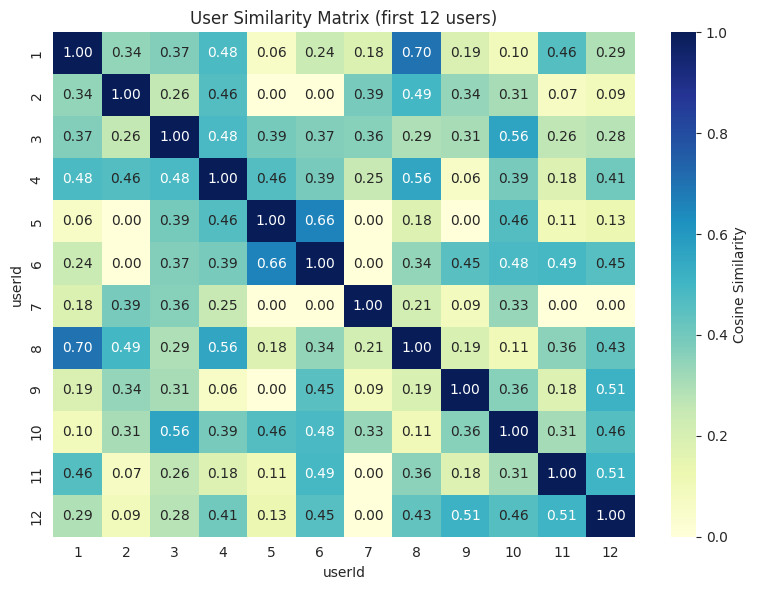

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(user_sim_df.iloc[:12, :12], cmap='YlGnBu', annot=True, fmt='.2f',
            cbar_kws={'label': 'Cosine Similarity'}, ax=ax)
ax.set_title('User Similarity Matrix (first 12 users)')
plt.tight_layout(); plt.show()

## 5. Key Findings

- **Content-based filtering** works well immediately for any movie (even brand-new ones
  with no ratings yet — the "cold start" problem) since it only needs genre metadata.
  It tends to recommend *very similar* movies, which can feel repetitive.
- **Collaborative filtering** captures patterns content-based filtering can't — e.g.
  "people who like X also unexpectedly like Y" — but needs enough rating history per
  user/movie to work well, and struggles with brand-new users or movies (cold start).
- In production recommender systems, these are typically **combined** (hybrid
  approach): content-based to handle cold start, collaborative to capture deeper
  behavioral patterns as data accumulates.

### Next steps to extend this
- Try item-based collaborative filtering (movie-movie similarity instead of user-user)
- Add matrix factorization (SVD) for collaborative filtering at scale
- Build a hybrid scorer that blends both similarity scores
- Swap in the real MovieLens dataset (ml-latest-small) for richer results
